# Exploración rápida del pipeline AUV

Ejecuta cada sección de forma independiente para verificar una etapa del modelo.
El dataset esperado es `data/lima3.nc` (Copernicus Marine / CMEMS).

**Secciones**
1. Setup
2. Datos — cargar y revisar el campo de corrientes
3. Zonas — divergencia, waypoints y centinelas
4. Grafo — construcción y estadísticos
5. Algoritmos — Bellman-Ford, matriz de costos y ATSP
6. Visualizaciones — campo, zonas, ruta 2D/3D y batería

## 1 · Setup

In [1]:
import sys, math, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.config import ParametrosModelo
from src import datos, grafo as grafo_mod, zonas, algoritmos, visualizacion, metricas

NC = pathlib.Path('..') / 'data' / 'lima3.nc'
print('Dataset:', NC.resolve())
print('Existe:', NC.exists())

Dataset: /home/axis/axis/Dev/UPC /26-1/Complejidad Algoritmica/TP-TF/TF-auv/data/lima3.nc
Existe: True


## 2 · Datos
Carga el NetCDF y muestra dimensiones, porcentaje de tierra y estadísticos de rapidez.

In [2]:
params = ParametrosModelo()
campo  = datos.cargar_corrientes(str(NC))
print(datos.resumen(campo))

Malla: 4 prof x 21 lat x 23 lon = 1932 celdas
Agua navegable: 1568  |  Tierra (NaN): 364 (18.8 %)
Latitud:  -13.08 .. -11.42
Longitud: -78.42 .. -76.58
Profundidades [m]: [0.49, 1.54, 2.65, 3.82]
Rapidez [m/s]: media 0.243  máx 0.601


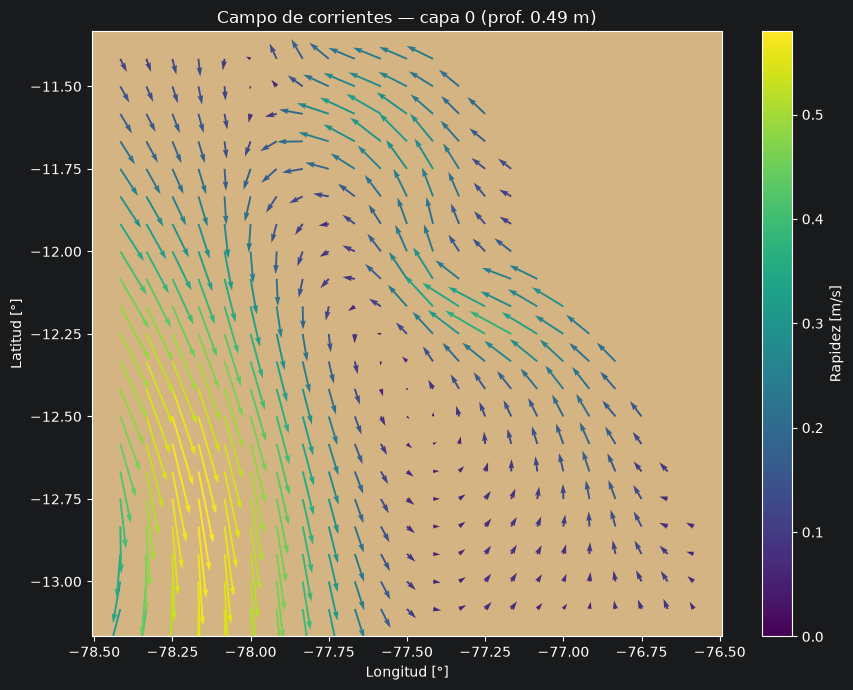

In [3]:
# Vista rápida del campo vectorial (capa 0 = superficie)
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_campo(campo, capa=0, ax=ax)
plt.tight_layout()
plt.show()

## 3 · Zonas
Calcula divergencia, selecciona waypoints de convergencia, centinelas offshore y fija la base en el Callao.

In [4]:
CAPA = 0

lat_media = math.radians(float(campo.lat.mean()))
dy = abs(float(campo.lat[1] - campo.lat[0])) * 111_320.0
dx = abs(float(campo.lon[1] - campo.lon[0])) * 111_320.0 * math.cos(lat_media)

uo  = campo.uo[CAPA]
vo  = campo.vo[CAPA]
nav = campo.navegable[CAPA]

div  = zonas.divergencia(uo, vo, dx, dy)
wps  = zonas.seleccionar_waypoints(div, nav, params.k_zonas, capa=CAPA, dist_min_celdas=3)
cent = zonas.seleccionar_centinelas(uo, vo, nav, campo.lon, n=2, capa=CAPA)
base = zonas.celda_mas_cercana(-12.05, -77.15, campo.lat, campo.lon, nav, capa=CAPA)

print(f'Waypoints de convergencia ({len(wps)}):')
for wp in wps:
    p, i, j = wp
    print(f'  {wp}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°  div={div[i,j]:.6f}')

print(f'\nCentinelas offshore ({len(cent)}):')
for c in cent:
    p, i, j = c
    print(f'  {c}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°  uo={uo[i,j]:.3f} m/s')

p, i, j = base
print(f'\nBase (Callao): {base}  lat={campo.lat[i]:.3f}°  lon={campo.lon[j]:.3f}°')

todos, base_nodo = zonas.agregar_puntos_fijos(wps + cent, wps[0], base)
base_idx = todos.index(base_nodo)
print(f'\nTotal waypoints misión: {len(todos)}  →  {math.factorial(len(todos)-1)} órdenes ATSP')

Waypoints de convergencia (6):
  (0, 10, 13)  lat=-12.250°  lon=-77.333°  div=-0.000006
  (0, 20, 9)  lat=-11.417°  lon=-77.667°  div=-0.000006
  (0, 17, 6)  lat=-11.667°  lon=-77.917°  div=-0.000004
  (0, 11, 16)  lat=-12.167°  lon=-77.083°  div=-0.000004
  (0, 2, 21)  lat=-12.917°  lon=-76.667°  div=-0.000003
  (0, 20, 3)  lat=-11.417°  lon=-78.167°  div=-0.000002

Centinelas offshore (2):
  (0, 11, 0)  lat=-12.167°  lon=-78.417°  uo=0.237 m/s
  (0, 6, 5)  lat=-12.583°  lon=-78.000°  uo=0.118 m/s

Base (Callao): (0, 12, 15)  lat=-12.083°  lon=-77.167°

Total waypoints misión: 9  →  40320 órdenes ATSP


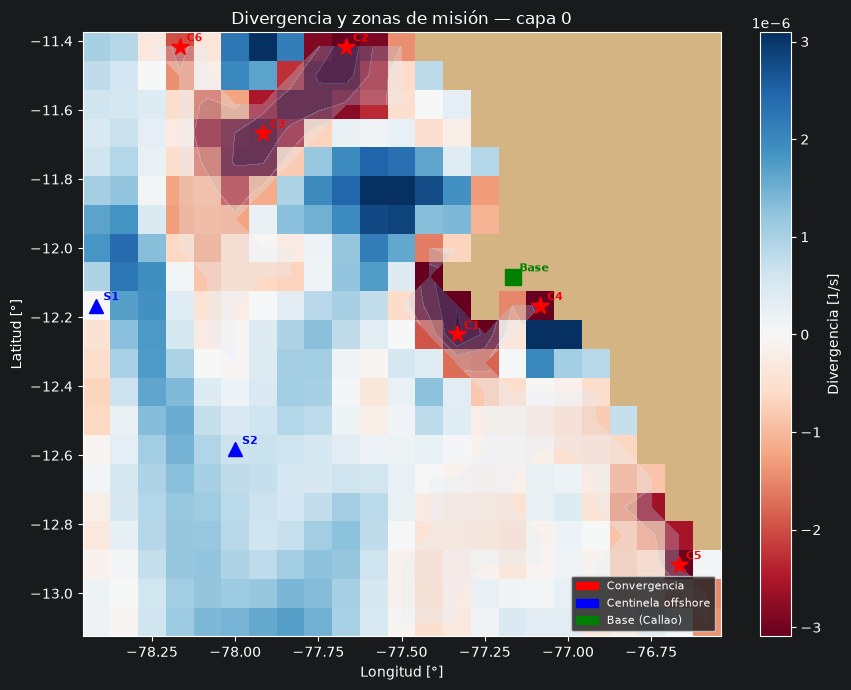

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_zonas(campo, div, wps, centinelas=cent, base=base, capa=CAPA, ax=ax)
plt.tight_layout()
plt.show()

## 4 · Grafo
Construye el grafo dirigido ponderado. Puede tardar ~1 min según tamaño del dominio.

In [6]:
g = grafo_mod.construir_grafo(campo, params)
print(f'Nodos:   {g.num_nodos:,}')
print(f'Aristas: {g.num_aristas:,}')
print(f'Factor de ramificación medio: {g.num_aristas / g.num_nodos:.1f}')

# Distribución de pesos (muestra del 1 % de las aristas)
pesos = np.array([w for _, _, w in g.aristas()])
print(f'\nPesos [J]  min={pesos.min():.2f}  media={pesos.mean():.2f}  max={pesos.max():.2f}')
print(f'Aristas negativas (regeneración): {(pesos < 0).sum():,} ({100*(pesos<0).mean():.1f} %)')

Nodos:   1,568
Aristas: 31,232
Factor de ramificación medio: 19.9

Pesos [J]  min=3.14  media=36614.44  max=145623.47
Aristas negativas (regeneración): 0 (0.0 %)


## 5 · Algoritmos
Bellman-Ford desde cada waypoint, detección de ciclos negativos, matriz de costos y resolución ATSP.

In [7]:
# Ciclos negativos (control de sanidad del modelo)
dist0, _ = algoritmos.bellman_ford(g, todos[0])
if algoritmos.hay_ciclo_negativo(g, dist0):
    print('⚠  Ciclo negativo detectado — revisar parámetros del modelo')
else:
    print('✓  Sin ciclos negativos')

✓  Sin ciclos negativos


In [8]:
# Matriz de costos entre zonas (un Bellman-Ford por waypoint)
M, caminos = algoritmos.matriz_costos(g, todos)

print('Matriz de costos [J]  (filas=origen, cols=destino):')
print(np.array2string(M, precision=1, suppress_small=True))

Matriz de costos [J]  (filas=origen, cols=destino):
[[     0.  136693.6 136187.  154470.8 421478.1 232134.  293317.5 178306.9
  105214.8]
 [366084.4      0.   92284.1 478721.  537060.2 126598.2 259054.2 205316.3
  453764.6]
 [273817.3 164340.9      0.  386454.  444793.2 130305.  166787.1 113049.3
  368120.9]
 [ 53818.2 152683.6 158579.5      0.  427468.3 254526.4 316938.2 211275.9
   15964.6]
 [182212.3 302024.1 306750.5 177991.6      0.  402697.5 465109.3 359446.9
  193956.2]
 [317700.1 189158.1  85860.  422062.7 474728.2      0.  161837.5 142752.1
  419436.5]
 [284202.  393009.4 368855.2 353907.5 366837.8 476299.7      0.   30794.9
  360060.1]
 [258501.5 387408.6 386902.  323135.4 336065.7 482848.9 544032.4      0.
  330747.1]
 [ 63967.6 136719.1 150387.7  65681.8 485427.  240077.2 317171.6 216764.5
       0. ]]


In [9]:
# ATSP por fuerza bruta
orden, costo_total = algoritmos.atsp_fuerza_bruta(M, base=base_idx)
ruta = algoritmos.ensamblar_ruta(orden, caminos)

print(f'Orden óptimo de visita: {orden}')
print(f'Costo total:            {costo_total:.2f} J')
print(f'Nodos en la ruta:       {len(ruta)}')
print()
print(metricas.resumen_mision(orden, todos, M, campo))

Orden óptimo de visita: [8, 0, 1, 5, 2, 6, 7, 4, 3, 8]
Costo total:            1140723.31 J
Nodos en la ruta:       82

── Resultado de la misión ──────────────────────
  Tramo 1: zona 8 (-12.08°,-77.17°) → zona 0 (-12.25°,-77.33°)     63967.6 J
  Tramo 2: zona 0 (-12.25°,-77.33°) → zona 1 (-11.42°,-77.67°)    136693.6 J
  Tramo 3: zona 1 (-11.42°,-77.67°) → zona 5 (-11.42°,-78.17°)    126598.2 J
  Tramo 4: zona 5 (-11.42°,-78.17°) → zona 2 (-11.67°,-77.92°)     85860.0 J
  Tramo 5: zona 2 (-11.67°,-77.92°) → zona 6 (-12.17°,-78.42°)    166787.1 J
  Tramo 6: zona 6 (-12.17°,-78.42°) → zona 7 (-12.58°,-78.00°)     30794.9 J
  Tramo 7: zona 7 (-12.58°,-78.00°) → zona 4 (-12.92°,-76.67°)    336065.7 J
  Tramo 8: zona 4 (-12.92°,-76.67°) → zona 3 (-12.17°,-77.08°)    177991.6 J
  Tramo 9: zona 3 (-12.17°,-77.08°) → zona 8 (-12.08°,-77.17°)     15964.6 J
──────────────────────────────────────────────────
  Energía total de la misión:    1140723.3 J


## 6 · Visualizaciones

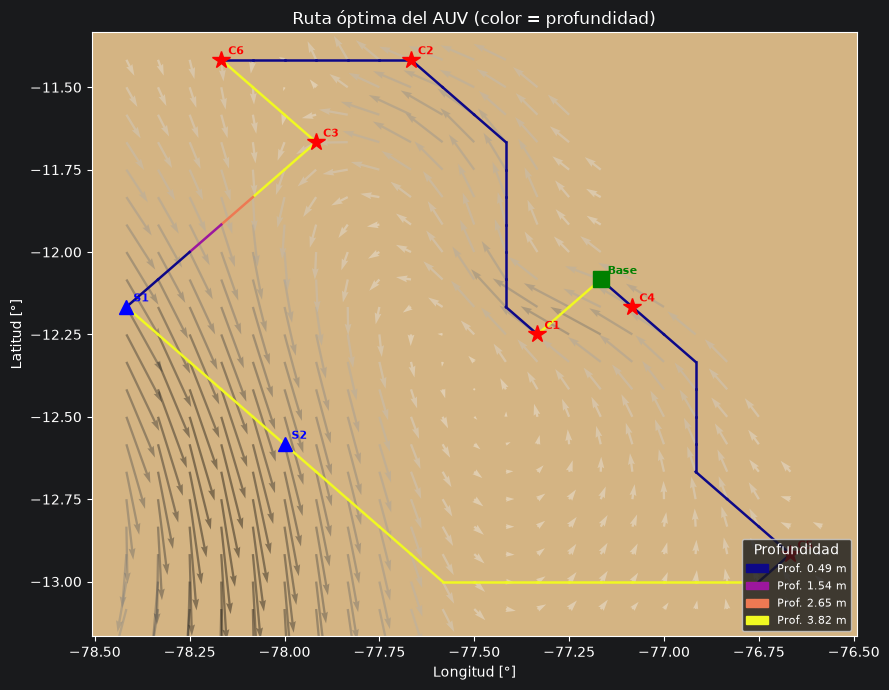

In [10]:
# Ruta óptima 2D
fig, ax = plt.subplots(figsize=(9, 7))
visualizacion.plot_ruta(campo, ruta, waypoints=wps, centinelas=cent, base=base, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
# Ruta 3D por capas de profundidad
fig3d = visualizacion.plot_3d(campo, ruta, waypoints=wps, centinelas=cent, base=base)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Viable: True  |  Mínimo: 859276.7 J  |  Consumido: 1140723.3 J  |  Regenerado: 0.0 J


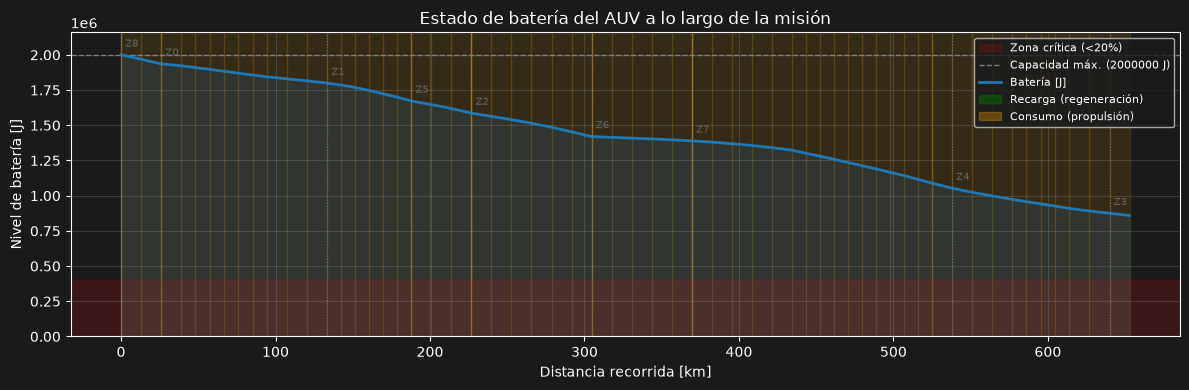

In [12]:
# Estado de batería a lo largo de la misión
bat = metricas.estado_bateria(ruta, g, params.e_max)
print(f"Viable: {bat['viable']}  |  Mínimo: {bat['minimo']:.1f} J  |  "
      f"Consumido: {bat['consumido']:.1f} J  |  Regenerado: {bat['regenerado']:.1f} J")

fig, ax = plt.subplots(figsize=(12, 4))
visualizacion.plot_bateria(campo, ruta, bat['niveles'], params.e_max,
                           waypoints=todos, orden=orden, ax=ax)
plt.tight_layout()
plt.show()

## Extras — pruebas puntuales
Zona de scratch para probar cosas sueltas sin tocar las secciones de arriba.

In [13]:
# Ejemplo: cambiar parámetros y ver cómo cambia la energía total
params_prueba = ParametrosModelo(s=1.0, eta=0.5, k_zonas=4)
print(params_prueba)

ParametrosModelo(s=1.0, k_p=3.0, k_r=1.0, eta=0.5, e_max=2000000.0, k_zonas=4, resolucion_grados=0.08333333333333333)
